In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns


In [43]:
data = {
    "StudyHours":[2,5,8,3,7,1,6,4,9,2,5,6,1,3,8,7,4,9,10,2],
    "Attendance":[60,80,90,70,85,60,78,65,95,55,76,88,40,60,92,84,66,97,99,53],
    "PastScore":[40,60,75,50,70,30,68,55,80,35,65,72,25,45,78,69,58,85,90,32],
    "Internet" :["YES","NO","YES","YES","NO","YES","NO","NO","YES","YES","NO","NO","YES","NO","NO","YES","NO","YES","YES","NO"],
    "SleepHours":[8,6,8,5,7,4,6,5,9,4,6,7,3,4,8,7,5,9,10,3],
    "Passed":["YES","NO","YES","NO","YES","NO","YES","NO","YES","NO","NO","YES","NO","NO","NO","YES","YES","YES","YES","NO"]
}



df = pd.DataFrame(data=data)

print("Sample Rows")
print(df.head(3))

print("Dataset Shape :")
print(df.shape)

print("Dataset INfo")
print(df.info())

print("Summary statics")
print(df.describe())

print("Missing Values")
print(df.isnull().sum())

Sample Rows
   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           2          60         40      YES           8    YES
1           5          80         60       NO           6     NO
2           8          90         75      YES           8    YES
Dataset Shape :
(20, 6)
Dataset INfo
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   SleepHours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB
None
Summary statics
       StudyHours  Attendance  PastScore  SleepHours
count   20.000000   20.000000   20.00000   20.000000
mean     5.100000   74.650000   59.10000    6.200000
std      2.845125   16.774903   19.4121

In [44]:
# now encoding  

le = LabelEncoder()

print("Missing Values :")
print(df.isnull().sum())

df['Internet'] = le.fit_transform(df['Internet'])
df["Passed"] = le.fit_transform(df['Passed'])

print("\nAfter Encoding")
print(df.head(10))

print("\nData types after cleaning :")
print(df.dtypes)



Missing Values :
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64

After Encoding
   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           2          60         40         1           8       1
1           5          80         60         0           6       0
2           8          90         75         1           8       1
3           3          70         50         1           5       0
4           7          85         70         0           7       1
5           1          60         30         1           4       0
6           6          78         68         0           6       1
7           4          65         55         0           5       0
8           9          95         80         1           9       1
9           2          55         35         1           4       0

Data types after cleaning :
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
SleepHours  

Classification Report :
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



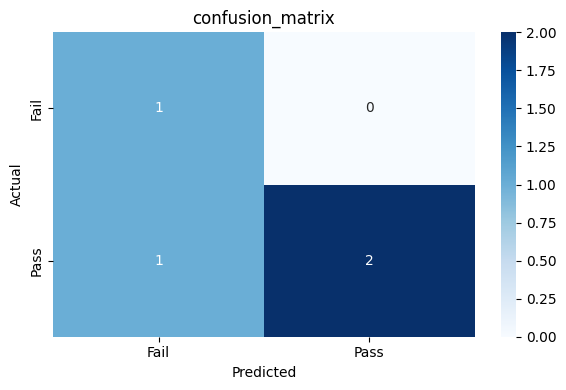

======Predict your Result=====
Prediction Based on input : Pass


/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [45]:
# feature Scaling

features = ["StudyHours","Attendance","PastScore","SleepHours"]
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])


# spliting data :

x = df_scaled[features]
y = df_scaled["Passed"]

x_train,x_test , y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = LogisticRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

# model evaluation

print("Classification Report :")
print(classification_report(y_test,y_pred))

conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix,annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion_matrix")
plt.tight_layout()
plt.show()

print("======Predict your Result=====")
try:
    study_hours = float(input("Enter study hours : "))
    atttendance = float(input("Enter attendence : "))
    pastscore = float(input("Enter past score : "))
    sleephours = float(input("Enter sleep hours : "))

    user_input_df = pd.DataFrame([{
        "StudyHours": study_hours,
        "Attendance": atttendance,
        "PastScore": pastscore,
        "SleepHours" : sleephours
    }])

    user_input_scaled = scaler.transform(user_input_df)

    prediction = model.predict(user_input_scaled)[0]
    
    result = "Pass" if prediction == 1 else "Fail"

    print(f"Prediction Based on input : {result}" )
except Exception as e:
    print("An error occured ")